Практика 4
Студент Карелин Д.В.
Вариант 6

**Задание 1**

Генерация набора данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

X = np.linspace(-3, 3, 120).reshape(-1,1)
y = np.sin(X).ravel() + np.random.normal(0,0.15,120)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Построение моделей степени 2 и 15

In [ ]:
degrees = [2, 15]

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for d in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("lin", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    print(f"\nСтепень полинома: {d}")
    print("Train MSE:", mean_squared_error(y_train, y_train_pred))
    print("Test MSE:", mean_squared_error(y_test, y_test_pred))
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2:", r2_score(y_test, y_test_pred))


Степень полинома: 2
Train MSE: 0.20404258669063025
Test MSE: 0.18680396328616425
Train R2: 0.6345246829242965
Test R2: 0.668903575668295

Степень полинома: 15
Train MSE: 0.015529594059703463
Test MSE: 0.026496304422463653
Train R2: 0.972183829831404
Test R2: 0.9530372295215012


График зависимости ошибки от степени полинома

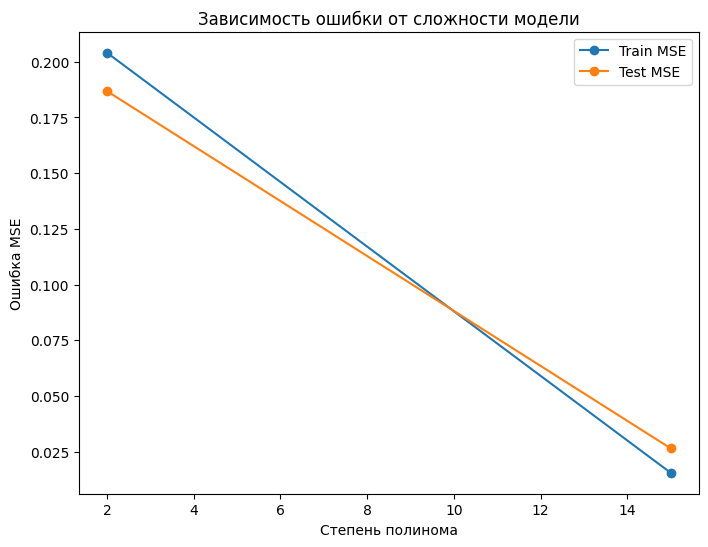

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(degrees, train_mse, marker='o', label="Train MSE")
plt.plot(degrees, test_mse, marker='o', label="Test MSE")

plt.xlabel("Степень полинома")
plt.ylabel("Ошибка MSE")
plt.title("Зависимость ошибки от сложности модели")
plt.legend()

plt.show()

График показывает изменение ошибки при увеличении степени полинома.
Ошибка на тренировочных данных уменьшается при росте сложности модели, однако ошибка на тестовых данных может увеличиваться из-за переобучения.

Визуализация моделей

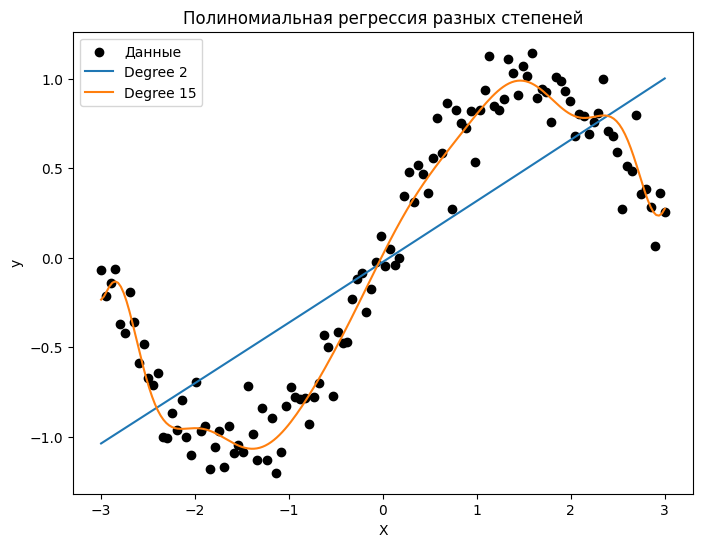

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color="black", label="Данные")

x_plot = np.linspace(-3,3,200).reshape(-1,1)

for d in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("lin", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_plot = model.predict(x_plot)

    plt.plot(x_plot, y_plot, label=f"Degree {d}")

plt.legend()
plt.title("Полиномиальная регрессия разных степеней")
plt.xlabel("X")
plt.ylabel("y")

plt.show()

Полином степени 2 описывает общий тренд данных и остаётся гладким.
Полином степени 15 начинает сильно колебаться и подстраиваться под шум обучающих данных, что является признаком переобучения.

Выводы:
Полином степени 2 описывает общий тренд данных и остаётся гладким.
Полином степени 15 начинает сильно колебаться и подстраиваться под шум обучающих данных, что является признаком переобучения.

**Задание 2**

Генерация и подготовка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Фиксируем случайность
np.random.seed(42)

# Загружаем датасет Diabetes
X, y = load_diabetes(return_X_y=True)

# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Обучение моделей Ridge и Lasso с подбором alpha

In [ ]:

alphas = np.logspace(-3, 3, 50)

# RidgeCV с 5-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
nonzero_ridge = np.sum(ridge_cv.coef_ != 0)

# LassoCV с 5-fold cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
nonzero_lasso = np.sum(lasso_cv.coef_ != 0)

# Вывод метрик
print("Результаты сравнения Ridge и Lasso:")
print(f"Ridge: alpha={ridge_cv.alpha_:.3f}, RMSE={rmse_ridge:.2f}, Non-zero coef={nonzero_ridge}")
print(f"Lasso: alpha={lasso_cv.alpha_:.3f}, RMSE={rmse_lasso:.2f}, Non-zero coef={nonzero_lasso}")

Результаты сравнения Ridge и Lasso:
Ridge: alpha=1.151, RMSE=53.77, Non-zero coef=10
Lasso: alpha=1.526, RMSE=52.93, Non-zero coef=7


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Визуализация коэффициентов моделей

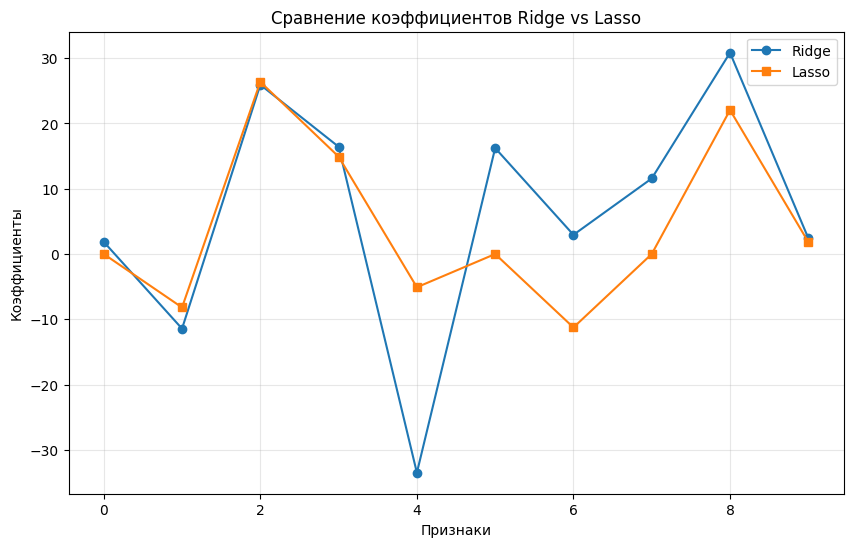

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(ridge_cv.coef_, marker='o', label='Ridge')
plt.plot(lasso_cv.coef_, marker='s', label='Lasso')
plt.xlabel('Признаки')
plt.ylabel('Коэффициенты')
plt.title('Сравнение коэффициентов Ridge vs Lasso')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ridge сохраняет все коэффициенты ненулевыми, просто "сжимая" их. Даже менее значимые признаки имеют небольшой вес.
Lasso обнуляет ряд коэффициентов, создавая разреженное решение. Это хорошо для отбора признаков.
На графике видно, что Lasso явно выделяет более значимые признаки, а неважные исчезают.

Ridge подходит, когда важны все признаки и требуется небольшое регуляризующее сжатие коэффициентов.
Lasso подходит для отбора признаков: обнуляет менее важные коэффициенты, что делает модель более интерпретируемой.
В задачах с большим количеством признаков и желанием выделить ключевые переменные стоит использовать Lasso.
Если цель — минимизация RMSE без отбора признаков, лучше Ridge.

**Задание 3**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score

# Загрузка датасета
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Отбор признаков с помощью SelectKBest (top-6)

In [ ]:
# Блок [2] – Фильтр SelectKBest
top_k = 6

selector = SelectKBest(score_func=f_regression, k=top_k)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Выбранные признаки (SelectKBest):", list(selected_features))

Выбранные признаки (SelectKBest): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


Отбор признаков с помощью Lasso

In [ ]:
alpha_lasso = 0.01  # небольшой параметр регуляризации

lasso = Lasso(alpha=alpha_lasso, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Выбираем признаки с ненулевыми коэффициентами
selected_lasso_features = X.columns[lasso.coef_ != 0]
print("Выбранные признаки (Lasso):", list(selected_lasso_features))

Выбранные признаки (Lasso): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']


Сравнение моделей: Полный набор и отобранные признаки

In [ ]:
models = {
    "Full": X_train_scaled,
    "SelectKBest": X_train_kbest,
    "Lasso": X_train_scaled[:, lasso.coef_ != 0]
}

results = {}

for name, X_model in models.items():
    start_time = time.time()
    lr = LinearRegression()
    lr.fit(X_model, y_train)
    elapsed = time.time() - start_time

    # Предсказания
    if name == "Full":
        y_pred = lr.predict(X_test_scaled)
    else:
        X_test_model = X_test_scaled[:, selector.get_support()] if name=="SelectKBest" else X_test_scaled[:, lasso.coef_ != 0]
        y_pred = lr.predict(X_test_model)

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "Time": elapsed
    }

# Вывод результатов
import pprint
pprint.pprint(results)

{'Full': {'R2': 0.5957702326061664, 'Time': 0.018097877502441406},
 'Lasso': {'R2': 0.5957536316726515, 'Time': 0.013096094131469727},
 'SelectKBest': {'R2': 0.594970214672015, 'Time': 0.010545969009399414}}


SelectKBest выбирает top-6 признаков, которые наиболее коррелируют с целевой переменной, не учитывая взаимодействие между признаками. Lasso автоматически обнуляет малозначимые коэффициенты, выполняя встроенный отбор признаков.

График R² и времени обучения

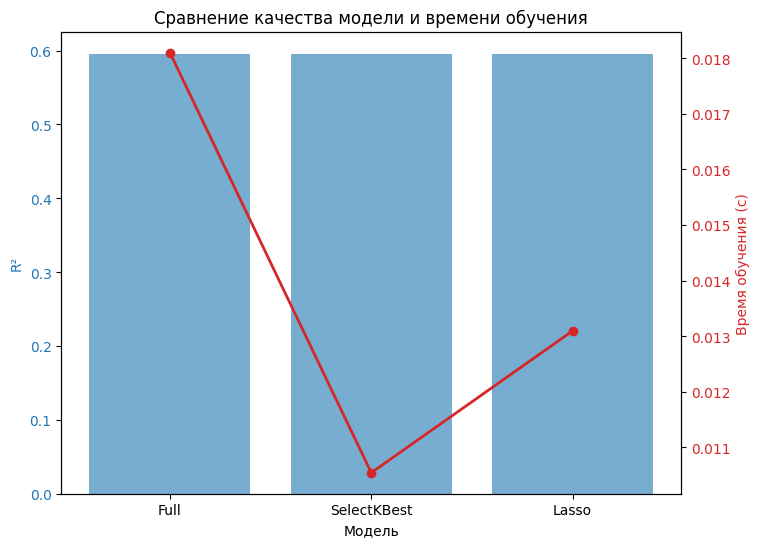

In [ ]:
labels = list(results.keys())
r2_scores = [results[l]["R2"] for l in labels]
times = [results[l]["Time"] for l in labels]

fig, ax1 = plt.subplots(figsize=(8,6))

color = 'tab:blue'
ax1.set_xlabel('Модель')
ax1.set_ylabel('R²', color=color)
ax1.bar(labels, r2_scores, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Время обучения (с)', color=color)
ax2.plot(labels, times, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Сравнение качества модели и времени обучения")
plt.show()

График показывает, что использование отобранных признаков сокращает размерность модели. R² почти не снижается по сравнению с полной моделью, а время обучения заметно уменьшается, особенно при большом числе признаков.

Выводы: удалось сократить размерность до 6 признаков без значительной потери качества. Для данного датасета Lasso немного лучше, так как учитывает взаимодействия между признаками и автоматически отбирает важные коэффициенты.